# Importing libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('audit_data.csv')

# First look
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

Shape: (776, 27)

Column names:
 ['Sector_score', 'LOCATION_ID', 'PARA_A', 'Score_A', 'Risk_A', 'PARA_B', 'Score_B', 'Risk_B', 'TOTAL', 'numbers', 'Score_B.1', 'Risk_C', 'Money_Value', 'Score_MV', 'Risk_D', 'District_Loss', 'PROB', 'RiSk_E', 'History', 'Prob', 'Risk_F', 'Score', 'Inherent_Risk', 'CONTROL_RISK', 'Detection_Risk', 'Audit_Risk', 'Risk']

First 5 rows:
    Sector_score LOCATION_ID  PARA_A  Score_A  Risk_A  PARA_B  Score_B  Risk_B  \
0          3.89          23    4.18      0.6   2.508    2.50      0.2   0.500   
1          3.89           6    0.00      0.2   0.000    4.83      0.2   0.966   
2          3.89           6    0.51      0.2   0.102    0.23      0.2   0.046   
3          3.89           6    0.00      0.2   0.000   10.80      0.6   6.480   
4          3.89           6    0.00      0.2   0.000    0.08      0.2   0.016   

   TOTAL  numbers  ...  RiSk_E  History  Prob  Risk_F  Score  Inherent_Risk  \
0   6.68      5.0  ...     0.4        0   0.2     0.0    2.4     

# Checking data quality

In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

quality_report = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct,
    'Data Type': df.dtypes
})

print("=== DATA QUALITY REPORT ===")
print(quality_report[quality_report['Missing Values'] > 0])
print(f"\nTotal records: {len(df)}")
print(f"Total columns: {df.shape[1]}")

=== DATA QUALITY REPORT ===
             Missing Values  Missing % Data Type
Money_Value               1       0.13   float64

Total records: 776
Total columns: 27


In [4]:
# Fill missing numeric values with column median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows")
print(f"Clean dataset: {len(df)} records")

# Save cleaned data
df.to_csv('audit_data_cleaned.csv', index=False)
print("Cleaned data saved.")

Removed 13 duplicate rows
Clean dataset: 763 records
Cleaned data saved.


# Risk distribution analysis

In [5]:
# Count risk vs non-risk
risk_counts = df['Risk'].value_counts()
print("Risk Distribution:")
print(risk_counts)
print(f"\nRisk Rate: {(risk_counts[1]/len(df)*100):.1f}%")

# Risk by sector
if 'LOCATION_ID' in df.columns:
    risk_by_sector = df.groupby('LOCATION_ID')['Risk'].agg(['sum','count','mean'])
    risk_by_sector.columns = ['High_Risk_Count', 'Total', 'Risk_Rate']
    risk_by_sector['Risk_Rate'] = (risk_by_sector['Risk_Rate']*100).round(1)
    risk_by_sector = risk_by_sector.sort_values('Risk_Rate', ascending=False)
    print("\nRisk by Sector (Top 10):")
    print(risk_by_sector.head(10))

Risk Distribution:
Risk
0    459
1    304
Name: count, dtype: int64

Risk Rate: 39.8%

Risk by Sector (Top 10):
             High_Risk_Count  Total  Risk_Rate
LOCATION_ID                                   
42                         1      1      100.0
34                         1      1      100.0
33                         1      1      100.0
24                         1      1      100.0
23                         1      1      100.0
41                         1      1      100.0
44                         1      1      100.0
39                         8      9       88.9
1                          9     11       81.8
20                         4      5       80.0


# Anomaly detection using Z-score (flags unusual financial values)

In [6]:
from scipy import stats

# Pick key financial columns to check
financial_cols = ['Money_Value', 'PARA_A', 'PARA_B', 'TOTAL']
available_cols = [c for c in financial_cols if c in df.columns]

# Z-score: values beyond 3 standard deviations = anomaly
z_scores = np.abs(stats.zscore(df[available_cols]))
anomaly_mask = (z_scores > 3).any(axis=1)

df['Anomaly_Flag'] = anomaly_mask.astype(int)
anomaly_count = df['Anomaly_Flag'].sum()

print(f"Anomalies detected: {anomaly_count} records ({anomaly_count/len(df)*100:.1f}% of dataset)")
print("\nSample anomalous records:")
print(df[df['Anomaly_Flag']==1][available_cols + ['Risk','Anomaly_Flag']].head(10))

Anomalies detected: 11 records (1.4% of dataset)

Sample anomalous records:
     Money_Value  PARA_A   PARA_B    TOTAL  Risk  Anomaly_Flag
39        935.03    7.97    17.18    25.15     1             1
81        873.37   71.48    25.63    97.11     1             1
125        12.67   25.40    51.74    77.14     1             1
155        11.09   20.04    48.90    68.94     1             1
241        58.86    4.28  1264.63  1268.91     1             1
247       680.14    1.35     0.00     1.35     1             1
342       844.37   57.03   134.33   191.36     1             1
467         0.00   45.23    36.18    81.41     1             1
494       397.31   20.65     0.00     0.00     1             1
509         0.00   85.00     1.06    86.06     1             1


# Visulaisation

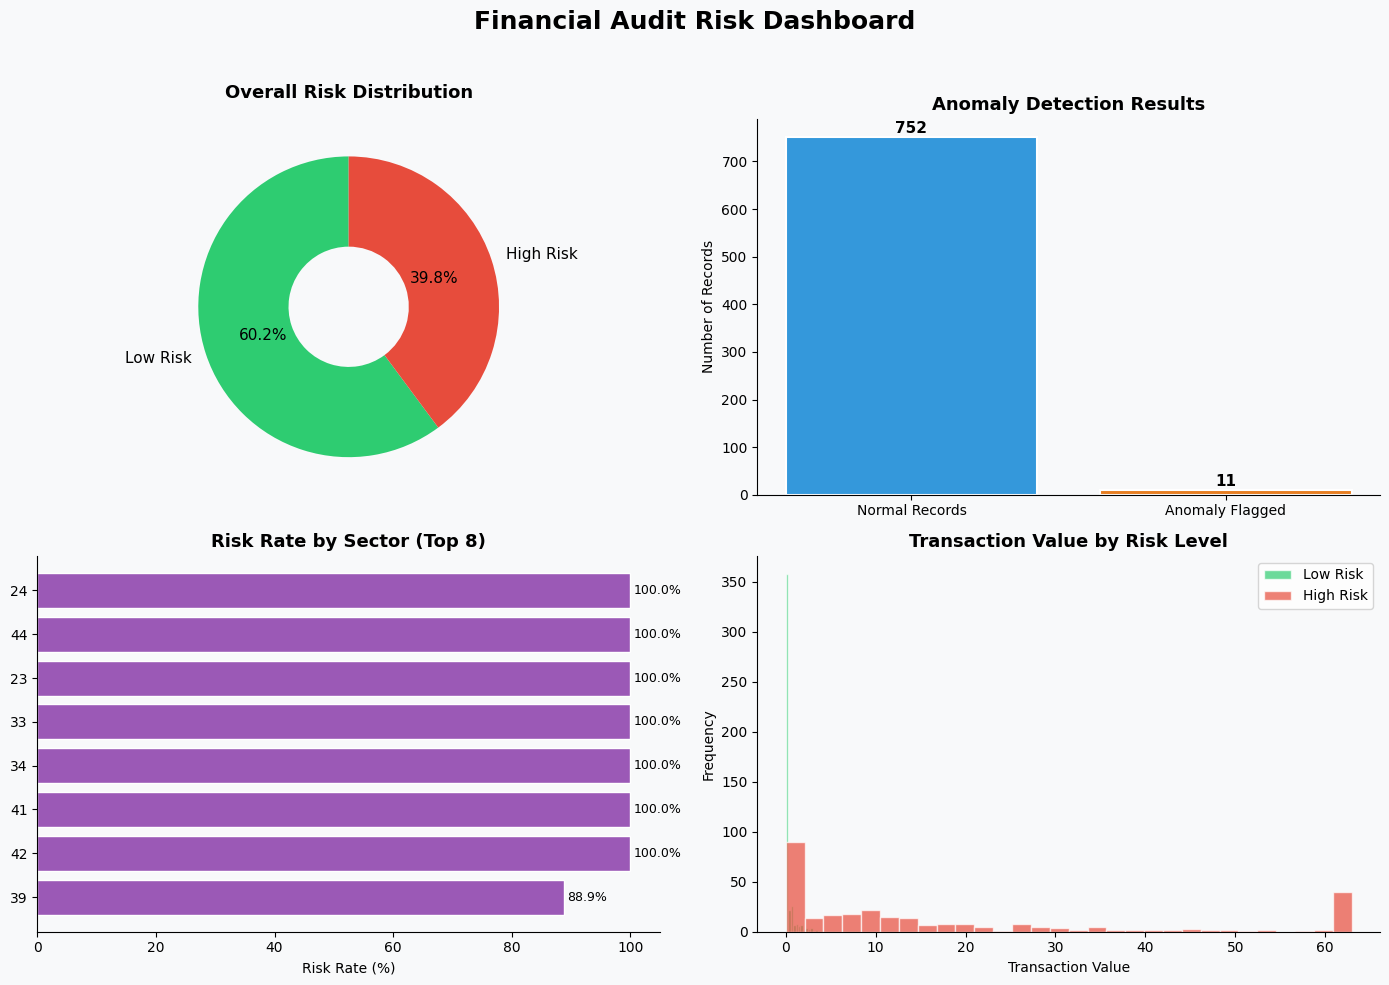

Dashboard saved as audit_dashboard.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Financial Audit Risk Dashboard', fontsize=18, fontweight='bold', y=0.98)
fig.patch.set_facecolor('#F8F9FA')

# ── Chart 1: Risk Distribution (Donut) ──────────────────────────
ax1 = axes[0, 0]
risk_labels = ['Low Risk', 'High Risk']
risk_vals = [df['Risk'].value_counts()[0], df['Risk'].value_counts()[1]]
colors = ['#2ECC71', '#E74C3C']
wedges, texts, autotexts = ax1.pie(
    risk_vals, labels=risk_labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.6), textprops={'fontsize': 11}
)
ax1.set_title('Overall Risk Distribution', fontsize=13, fontweight='bold', pad=15)

# ── Chart 2: Anomaly vs Normal Records (Bar) ────────────────────
ax2 = axes[0, 1]
anomaly_data = df['Anomaly_Flag'].value_counts().sort_index()
bars = ax2.bar(['Normal Records', 'Anomaly Flagged'],
               anomaly_data.values,
               color=['#3498DB', '#E67E22'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, anomaly_data.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('Anomaly Detection Results', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Records')
ax2.set_facecolor('#F8F9FA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Risk Rate by Sector (Horizontal Bar) ───────────────
ax3 = axes[1, 0]
if 'LOCATION_ID' in df.columns:
    sector_risk = df.groupby('LOCATION_ID')['Risk'].mean() * 100
    sector_risk = sector_risk.sort_values(ascending=True).tail(8)
    bars3 = ax3.barh(sector_risk.index.astype(str),
                     sector_risk.values,
                     color='#9B59B6', edgecolor='white')
    for bar, val in zip(bars3, sector_risk.values):
        ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
    ax3.set_title('Risk Rate by Sector (Top 8)', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Risk Rate (%)')
    ax3.set_facecolor('#F8F9FA')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

# ── Chart 4: Financial Value Distribution by Risk ───────────────
ax4 = axes[1, 1]
if 'Money_Value' in df.columns:
    low_risk = df[df['Risk']==0]['Money_Value'].clip(upper=df['Money_Value'].quantile(0.95))
    high_risk = df[df['Risk']==1]['Money_Value'].clip(upper=df['Money_Value'].quantile(0.95))
    ax4.hist(low_risk, bins=30, alpha=0.7, color='#2ECC71', label='Low Risk', edgecolor='white')
    ax4.hist(high_risk, bins=30, alpha=0.7, color='#E74C3C', label='High Risk', edgecolor='white')
    ax4.set_title('Transaction Value by Risk Level', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Transaction Value')
    ax4.set_ylabel('Frequency')
    ax4.legend(fontsize=10)
    ax4.set_facecolor('#F8F9FA')
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('audit_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Dashboard saved as audit_dashboard.png")

# Summary Report

In [8]:
# Export full annotated dataset to Excel
with pd.ExcelWriter('Audit_Analytics_Report.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Full Dataset', index=False)

    # Summary stats sheet
    summary = pd.DataFrame({
        'Metric': [
            'Total Records Analysed',
            'High Risk Records',
            'Overall Risk Rate (%)',
            'Anomalies Detected',
            'Anomaly Rate (%)',
            'Records After Cleaning',
            'Missing Values Filled'
        ],
        'Value': [
            len(df),
            int(df['Risk'].sum()),
            round(df['Risk'].mean()*100, 1),
            int(df['Anomaly_Flag'].sum()),
            round(df['Anomaly_Flag'].mean()*100, 1),
            len(df),
            int(missing.sum())
        ]
    })
    summary.to_excel(writer, sheet_name='Executive Summary', index=False)

print("Excel report exported: Audit_Analytics_Report.xlsx")
print("\n=== FINAL SUMMARY ===")
for _, row in summary.iterrows():
    print(f"  {row['Metric']}: {row['Value']}")

Excel report exported: Audit_Analytics_Report.xlsx

=== FINAL SUMMARY ===
  Total Records Analysed: 763.0
  High Risk Records: 304.0
  Overall Risk Rate (%): 39.8
  Anomalies Detected: 11.0
  Anomaly Rate (%): 1.4
  Records After Cleaning: 763.0
  Missing Values Filled: 1.0
